# DAS Event Classification - Results Visualization

This notebook generates all required figures for the paper comparing:
1. CNN Classifier
2. MLP Classifier  
3. Siamese Multi-Similarity Network

## For each model, we want the:
1. Training curves (loss + accuracy)
2. Confusion matrix
3. F1 score (macro, weighted)
4. Balanced accuracy

## For Siamese additionally:
- F1 for trained classes vs never-seen classes
- N-way K-shot results
- Novelty detection results

### Some imports...

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import seaborn as sn  # Alias used in pretty confusion matrix
import pandas as pd
import pickle
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

# Set style for publication-quality figures
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.format': 'pdf',  # Save as PDF
    'font.family': 'serif'
})

## 1. Load Results from All Models

In [14]:
# Define result directories (update these paths after training)
CNN_DIR = "cnn_results_20260120_094712"  
MLP_DIR = "mlp_results_20260122_040240"  # Best MLP: batch=256, dropout=0.3, 76.08%
SIAMESE_DIR = "siamese_multisim_20260122_132947"  # 9-class 10-shot: 46.38% (CORRECTED - fixed anomaly detection bug)
OUTPUT_DIR = "paper_figures"

Path(OUTPUT_DIR).mkdir(exist_ok=True)

def load_results(result_dir, model_name):
    """Load saved results from a training run."""
    results = {'name': model_name, 'dir': result_dir}
    
    # Try loading history (training curves)
    history_file = Path(result_dir) / 'history.npy'
    if history_file.exists():
        results['history'] = np.load(history_file, allow_pickle=True).item()
        print(f"✓ Loaded {model_name} training history")
    else:
        print(f"✗ {model_name} training history not found")
        results['history'] = None
    
    # Try loading test results
    test_file = Path(result_dir) / 'test_results.npy'
    if test_file.exists():
        results['test'] = np.load(test_file, allow_pickle=True).item()
        print(f"✓ Loaded {model_name} test results")
    else:
        print(f"✗ {model_name} test results not found")
        results['test'] = None
    
    # For Siamese, load additional results
    if model_name == 'Siamese':
        pkl_file = Path(result_dir) / 'all_results.pkl'
        if pkl_file.exists():
            with open(pkl_file, 'rb') as f:
                results['all_results'] = pickle.load(f)
            print(f"✓ Loaded {model_name} comprehensive results (pkl)")
    
    return results

In [15]:
# Load all results
print("Loading results...\n")
cnn_results = load_results(CNN_DIR, 'CNN')
mlp_results = load_results(MLP_DIR, 'MLP')
siamese_results = load_results(SIAMESE_DIR, 'Siamese')
print("\nDone!")

Loading results...

✓ Loaded CNN training history
✓ Loaded CNN test results
✓ Loaded MLP training history
✓ Loaded MLP test results
✓ Loaded Siamese training history
✓ Loaded Siamese test results
✓ Loaded Siamese comprehensive results (pkl)

Done!


## 2. Individual Model Visualizations

### 2.1 CNN Classifier

Ploting accuracy and loss...

In [16]:
def plot_loss_curve(history, model_name, filename):
    """Plot loss curve (train and validation)."""
    fig, ax = plt.subplots(figsize=(7, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss with markers
    ax.plot(epochs, history['train_loss'], 'b-', label='Train', linewidth=2, 
            marker='o', markersize=7, markevery=10, 
            markeredgecolor='white', markeredgewidth=1.5)
    ax.plot(epochs, history['val_loss'], 'r-', label='Validation', linewidth=2,
            marker='s', markersize=7, markevery=10,
            markeredgecolor='white', markeredgewidth=1.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    # No title - will be in LaTeX caption
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()
    print(f"✓ Saved: {filename}")

def plot_accuracy_curve(history, model_name, filename):
    """Plot accuracy curve (train and validation)."""
    fig, ax = plt.subplots(figsize=(7, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Determine accuracy key names (Siamese uses different keys)
    train_acc_key = 'train_pair_acc' if 'train_pair_acc' in history else 'train_acc'
    val_acc_key = 'val_pair_acc' if 'val_pair_acc' in history else 'val_acc'
    
    # Accuracy with markers
    ax.plot(epochs, history[train_acc_key], 'b-', label='Train', linewidth=2, 
            marker='o', markersize=7, markevery=10,
            markeredgecolor='white', markeredgewidth=1.5)
    ax.plot(epochs, history[val_acc_key], 'r-', label='Validation', linewidth=2, 
            marker='s', markersize=7, markevery=10,
            markeredgecolor='white', markeredgewidth=1.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    # No title - will be in LaTeX caption
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()
    print(f"✓ Saved: {filename}")

# Plot CNN curves
if cnn_results['history'] is not None:
    plot_loss_curve(
        cnn_results['history'],
        'CNN',
        f'{OUTPUT_DIR}/cnn_loss.pdf'
    )
    plot_accuracy_curve(
        cnn_results['history'],
        'CNN',
        f'{OUTPUT_DIR}/cnn_accuracy.pdf'
    )

✓ Saved: paper_figures/cnn_loss.pdf
✓ Saved: paper_figures/cnn_accuracy.pdf


Ploting confusion matrix...

In [68]:
# Pretty Confusion Matrix Functions
# Based on code by Wagner Cipriano and Phongsathorn Kittiworapanya
from pandas import DataFrame
from matplotlib.collections import QuadMesh
from matplotlib.colors import LinearSegmentedColormap

# Create a gradient from white to darker red for better visibility
colors = [(1.0, 0.95, 0.95), (0.95, 0.5, 0.45), (0.8, 0.2, 0.2)]
cm_cmap = LinearSegmentedColormap.from_list('cm_color', colors, N=256)

def get_new_fig(fn, figsize=[9,9]):
    """Init graphics"""
    fig1 = plt.figure(fn, figsize)
    ax1 = fig1.gca()    # Get Current Axis
    ax1.cla()   # clear existing plot
    return fig1, ax1

def configcell_text_and_colors(array_df, lin, col, oText, facecolors, posi, fz, fmt, show_null_values=0):
    """
    config cell text and colors
    and return text elements to add and to dell
    """
    text_add = []
    text_del = []
    cell_val = array_df[lin][col]
    tot_all = array_df[-1][-1]
    per = (float(cell_val) / tot_all) * 100
    curr_column = array_df[:,col]
    ccl = len(curr_column)

    # last line and/or last column
    if(col == (ccl - 1)) or (lin == (ccl - 1)):
        # tots and percents
        if(cell_val != 0):
            if(col == ccl - 1) and (lin == ccl - 1):
                tot_rig = 0
                for i in range(array_df.shape[0] - 1):
                    tot_rig += array_df[i][i]
                per_ok = (float(tot_rig) / cell_val) * 100
            elif(col == ccl - 1):
                tot_rig = array_df[lin][lin]
                per_ok = (float(tot_rig) / cell_val) * 100
            elif(lin == ccl - 1):
                tot_rig = array_df[col][col]
                per_ok = (float(tot_rig) / cell_val) * 100
            per_err = 100 - per_ok
        else:
            per_ok = per_err = 0

        per_ok_s = ['%.2f%%'%(per_ok), '100%'][int(per_ok == 100)]

        # text to DEL
        text_del.append(oText)

        # text to ADD
        font_prop = fm.FontProperties(size=fz)
        text_kwargs = dict(color='black', ha="center", va="center", gid='sum', fontproperties=font_prop)
        lis_txt = ['%d'%(cell_val), per_ok_s, '%.2f%%'%(per_err)]
        lis_kwa = [text_kwargs]
        dic = text_kwargs.copy(); dic['color'] = 'g'; lis_kwa.append(dic);
        dic = text_kwargs.copy(); dic['color'] = 'r'; lis_kwa.append(dic);
        lis_pos = [(oText._x, oText._y-0.25), (oText._x, oText._y), (oText._x, oText._y+0.25)]
        for i in range(len(lis_txt)):
            newText = dict(x=lis_pos[i][0], y=lis_pos[i][1], text=lis_txt[i], kw=lis_kwa[i])
            text_add.append(newText)

        # set background color for sum cells (last line and last column)
        carr = np.array([0.7, 0.7, 0.7, 1.0])
        if(col == ccl - 1) and (lin == ccl - 1):
            carr = np.array([0.5, 0.5, 0.5, 1.0])
        facecolors[posi] = carr

    else:
        if(per > 0):
            txt = '$\\mathbf{%s}$\n%.2f%%' %(cell_val, per)
        else:
            if(show_null_values == 0):
                txt = ''
            elif(show_null_values == 1):
                txt = '0'
            else:
                txt = '$\\mathbf{0}$\n0.0%%'
        oText.set_text(txt)

        # main diagonal
        if(col == lin):
            # set color of the text in the diagonal to black for visibility
            oText.set_color('black')
            # set background color in the diagonal to bright green
            facecolors[posi] = np.array([0.3, 0.9, 0.3, 1.0])

    return text_add, text_del

def insert_totals(df_cm):
    """insert total column and line (the last ones)"""
    sum_col = []
    for c in df_cm.columns:
        sum_col.append(df_cm[c].sum())
    sum_lin = []
    for item_line in df_cm.iterrows():
        sum_lin.append(item_line[1].sum())
    df_cm['sum_lin'] = sum_lin
    sum_col.append(np.sum(sum_lin))
    df_cm.loc['sum_col'] = sum_col

def plot_pretty_confusion_matrix(df_cm, annot=True, cmap=cm_cmap, fmt='.2f', fz=11,
      lw=2, cbar=False, figsize=[5,5], show_null_values=2, pred_val_axis='y'):
    """
    print conf matrix with default layout (like matlab)
    """
    if(pred_val_axis in ('col', 'x')):
        xlbl = 'Predicted'
        ylbl = 'Actual'
    else:
        xlbl = 'Actual'
        ylbl = 'Predicted'
        df_cm = df_cm.T

    # create "Total" column
    insert_totals(df_cm)

    # Create figure
    fig, ax1 = get_new_fig('Conf matrix default', figsize)

    # Get data as numpy array
    data = df_cm.values
    n_rows, n_cols = data.shape
    
    # Create custom color array for each cell
    # Start with all cells using the red colormap
    from matplotlib import cm as mpl_cm
    norm = plt.Normalize(vmin=data.min(), vmax=data.max())
    colors_matrix = np.zeros((n_rows, n_cols, 4))
    
    # Calculate separate normalizations for diagonal and sum cells
    diag_values = [data[i, i] for i in range(min(n_rows - 1, n_cols - 1))]
    sum_values = []
    for i in range(n_rows - 1):
        sum_values.append(data[i, n_cols - 1])
    for j in range(n_cols - 1):
        sum_values.append(data[n_rows - 1, j])
    
    norm_diag = plt.Normalize(vmin=min(diag_values) if diag_values else 0, vmax=max(diag_values) if diag_values else 1)
    norm_sum = plt.Normalize(vmin=min(sum_values) if sum_values else 0, vmax=max(sum_values) if sum_values else 1)
    
    # Apply colors based on cell type
    for i in range(n_rows):
        for j in range(n_cols):
            # Diagonal cells (excluding sum) - GREEN GRADIENT
            if i == j and i < n_rows - 1:
                val = norm_diag(data[i, j])
                # Green gradient: light green to darker green
                colors_matrix[i, j] = [0.7 - val * 0.5, 0.95 - val * 0.15, 0.7 - val * 0.5, 1.0]
            # Sum column (excluding corner) - LIGHT GREEN GRADIENT
            elif j == n_cols - 1 and i < n_rows - 1:
                val = norm_sum(data[i, j])
                colors_matrix[i, j] = [0.85 - val * 0.15, 0.95 - val * 0.1, 0.85 - val * 0.15, 1.0]
            # Sum row (excluding corner) - LIGHT GREEN GRADIENT
            elif i == n_rows - 1 and j < n_cols - 1:
                val = norm_sum(data[i, j])
                colors_matrix[i, j] = [0.85 - val * 0.15, 0.95 - val * 0.1, 0.85 - val * 0.15, 1.0]
            # Corner (total) - LIGHT GRAY
            elif i == n_rows - 1 and j == n_cols - 1:
                colors_matrix[i, j] = [0.9, 0.9, 0.9, 1.0]
            # All other cells - RED gradient (much stronger red)
            else:
                # Use red colormap with much stronger red color
                val = norm(data[i, j])
                # Range from light pink (low values) to strong red (high values)
                colors_matrix[i, j] = [1.0, 0.95 - val * 0.75, 0.95 - val * 0.75, 1.0]
    
    # Draw the heatmap using imshow with our custom colors
    ax1.imshow(colors_matrix, aspect='auto', interpolation='nearest')
    
    # Explicitly turn off grid
    ax1.grid(False)
    
    # Set limits
    ax1.set_xlim(-0.5, n_cols - 0.5)
    ax1.set_ylim(n_rows - 0.5, -0.5)
    
    # Turn off spines (borders)
    for spine in ax1.spines.values():
        spine.set_visible(False)
    
    # Turn off ticks
    ax1.tick_params(axis='both', which='both', length=0)
    
    # Set tick labels
    ax1.set_xticks(range(n_cols))
    ax1.set_yticks(range(n_rows))
    ax1.set_xticklabels(df_cm.columns, ha='right', rotation=45)
    ax1.set_yticklabels(df_cm.index, va='center')

    # Now add text annotations
    array_df = np.array(df_cm.to_records(index=False).tolist())
    for i in range(n_rows):
        for j in range(n_cols):
            cell_val = array_df[i][j]
            tot_all = array_df[-1][-1]
            per = (float(cell_val) / tot_all) * 100
            
            # Sum cells
            if i == n_rows - 1 or j == n_cols - 1:
                if cell_val != 0:
                    if i == n_rows - 1 and j == n_cols - 1:
                        tot_rig = sum(array_df[k][k] for k in range(n_rows - 1))
                        per_ok = (float(tot_rig) / cell_val) * 100
                    elif j == n_cols - 1:
                        tot_rig = array_df[i][i]
                        per_ok = (float(tot_rig) / cell_val) * 100
                    else:
                        tot_rig = array_df[j][j]
                        per_ok = (float(tot_rig) / cell_val) * 100
                    per_err = 100 - per_ok
                    per_ok_s = '100%' if per_ok == 100 else f'{per_ok:.2f}%'
                    
                    ax1.text(j, i - 0.25, f'{int(cell_val)}', 
                           ha='center', va='center', fontsize=fz, color='black')
                    ax1.text(j, i, per_ok_s, 
                           ha='center', va='center', fontsize=fz, color='g')
                    ax1.text(j, i + 0.25, f'{per_err:.2f}%', 
                           ha='center', va='center', fontsize=fz, color='r')
            # Regular cells
            else:
                if per > 0:
                    txt = f'$\\mathbf{{{int(cell_val)}}}$\n{per:.2f}%'
                else:
                    txt = '' if show_null_values == 0 else ('0' if show_null_values == 1 else '$\\mathbf{0}$\n0.0%')
                
                ax1.text(j, i, txt, ha='center', va='center', fontsize=fz, color='black')

    # Labels
    ax1.set_xlabel(xlbl, fontdict={"weight": "bold"})
    ax1.set_ylabel(ylbl, fontdict={"weight": "bold"})
    
    plt.tight_layout()

def plot_from_confusion_matrix(cm, columns=None, annot=True, cmap=cm_cmap,
      fmt='.2f', fz=11, lw=1, cbar=False, figsize=[5,5], show_null_values=2, pred_val_axis='lin'):
    """Plot confusion matrix from a confusion matrix array."""
    df_cm = DataFrame(cm, index=columns, columns=columns)
    plot_pretty_confusion_matrix(df_cm, fz=fz, lw=lw, cmap=cmap, figsize=figsize, show_null_values=show_null_values, pred_val_axis=pred_val_axis)

print("✓ Pretty confusion matrix functions loaded")

✓ Pretty confusion matrix functions loaded


In [69]:
def plot_confusion_matrix(cm, class_names, filename):
    """Plot confusion matrix using pretty visualization."""
    # Close any existing figures to avoid conflicts
    plt.close('all')
    
    # Use the pretty confusion matrix function
    plot_from_confusion_matrix(
        cm, 
        columns=class_names, 
        figsize=[9, 9], 
        fz=11, 
        lw=1, 
        show_null_values=2, 
        pred_val_axis='lin'
    )
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.close('all')
    print(f"✓ Saved: {filename}")

# Plot CNN confusion matrix
if cnn_results['test'] is not None and 'confusion_matrix' in cnn_results['test']:
    plot_confusion_matrix(
        cnn_results['test']['confusion_matrix'],
        cnn_results['test'].get('class_names', [f'Class {i}' for i in range(9)]),
        f'{OUTPUT_DIR}/cnn_confusion_matrix.pdf'
    )

✓ Saved: paper_figures/cnn_confusion_matrix.pdf


Ploting the results summary for this model...

In [19]:
def print_metrics_summary(test_results, model_name):
    """Print summary of key metrics."""
    print(f"\n{'='*60}")
    print(f"{model_name} - Test Results")
    print(f"{'='*60}")
    print(f"Accuracy:          {test_results.get('accuracy', 0):.4f}")
    print(f"Balanced Accuracy: {test_results.get('balanced_accuracy', 0):.4f}")
    print(f"F1 Score (Macro):  {test_results.get('f1_macro', 0):.4f}")
    print(f"F1 Score (Weighted): {test_results.get('f1_weighted', 0):.4f}")
    print(f"{'='*60}\n")

# Print CNN metrics
if cnn_results['test'] is not None:
    print_metrics_summary(cnn_results['test'], 'CNN')


CNN - Test Results
Accuracy:          0.8739
Balanced Accuracy: 0.6378
F1 Score (Macro):  0.6192
F1 Score (Weighted): 0.8563



### 2.2 MLP Classifier

Ploting accuracy, loss, confusion matrix, and results summary...

In [70]:
# Plot MLP curves
if mlp_results['history'] is not None:
    plot_loss_curve(
        mlp_results['history'],
        'MLP',
        f'{OUTPUT_DIR}/mlp_loss.pdf'
    )
    plot_accuracy_curve(
        mlp_results['history'],
        'MLP',
        f'{OUTPUT_DIR}/mlp_accuracy.pdf'
    )

# Plot MLP confusion matrix
if mlp_results['test'] is not None and 'confusion_matrix' in mlp_results['test']:
    plot_confusion_matrix(
        mlp_results['test']['confusion_matrix'],
        mlp_results['test'].get('class_names', [f'Class {i}' for i in range(9)]),
        f'{OUTPUT_DIR}/mlp_confusion_matrix.pdf'
    )

# Print MLP metrics
if mlp_results['test'] is not None:
    print_metrics_summary(mlp_results['test'], 'MLP')

✓ Saved: paper_figures/mlp_loss.pdf
✓ Saved: paper_figures/mlp_accuracy.pdf
✓ Saved: paper_figures/mlp_confusion_matrix.pdf

MLP - Test Results
Accuracy:          0.7608
Balanced Accuracy: 0.7157
F1 Score (Macro):  0.7212
F1 Score (Weighted): 0.7586



### 2.3 Siamese Multi-Similarity Network

Ploting accuracy, loss, confusion matrix, and results summary...

In [71]:
# Plot Siamese curves
if siamese_results['history'] is not None:
    plot_loss_curve(
        siamese_results['history'],
        'Siamese',
        f'{OUTPUT_DIR}/siamese_loss.pdf'
    )
    plot_accuracy_curve(
        siamese_results['history'],
        'Siamese',
        f'{OUTPUT_DIR}/siamese_accuracy.pdf'
    )

# Plot Siamese confusion matrix
if siamese_results['test'] is not None and 'confusion_matrix' in siamese_results['test']:
    plot_confusion_matrix(
        siamese_results['test']['confusion_matrix'],
        siamese_results['test'].get('class_names', [f'Class {i}' for i in range(9)]),
        f'{OUTPUT_DIR}/siamese_confusion_matrix.pdf'
    )

# Display metrics
if siamese_results['test'] is not None:
    print_metrics_summary(siamese_results['test'], 'Siamese')

✓ Saved: paper_figures/siamese_loss.pdf
✓ Saved: paper_figures/siamese_accuracy.pdf
✓ Saved: paper_figures/siamese_confusion_matrix.pdf

Siamese - Test Results
Accuracy:          0.4638
Balanced Accuracy: 0.4638
F1 Score (Macro):  0.4411
F1 Score (Weighted): 0.4411



## 3. Comparison Figures

Side-by-side comparison of all three models

In [ ]:
def plot_balanced_accuracy_comparison(cnn_test, mlp_test, siamese_test, filename):
    """Bar plot comparing balanced accuracy across all models."""
    models = []
    balanced_accs = []
    
    for name, results in [('CNN', cnn_test), ('MLP', mlp_test), ('Siamese', siamese_test)]:
        if results is not None and 'balanced_accuracy' in results:
            models.append(name)
            balanced_accs.append(results['balanced_accuracy'])
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    bars = ax.bar(models, balanced_accs, color=['blue', 'green', 'red'], alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bar, val in zip(bars, balanced_accs):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_ylabel('Balanced Accuracy')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    # No title - will be in LaTeX caption
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()
    print(f"✓ Saved: {filename}")

def plot_f1_score_comparison(cnn_test, mlp_test, siamese_test, filename):
    """Bar plot comparing F1 scores (macro and weighted) across all models."""
    models = []
    f1_macro = []
    f1_weighted = []
    
    for name, results in [('CNN', cnn_test), ('MLP', mlp_test), ('Siamese', siamese_test)]:
        if results is not None:
            models.append(name)
            f1_macro.append(results.get('f1_macro', 0))
            f1_weighted.append(results.get('f1_weighted', 0))
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    x = np.arange(len(models))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, f1_macro, width, label='F1 Macro', 
                   color='steelblue', alpha=0.8, edgecolor='black', linewidth=1.5)
    bars2 = ax.bar(x + width/2, f1_weighted, width, label='F1 Weighted', 
                   color='coral', alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}',
                    ha='center', va='bottom', fontsize=10)
    
    ax.set_ylabel('F1 Score')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylim([0, 1])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    # No title - will be in LaTeX caption
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()
    print(f"✓ Saved: {filename}")

# Plot comparison bar charts
plot_balanced_accuracy_comparison(
    cnn_results.get('test'),
    mlp_results.get('test'),
    siamese_results.get('test'),
    f'{OUTPUT_DIR}/comparison_balanced_accuracy.pdf'
)

plot_f1_score_comparison(
    cnn_results.get('test'),
    mlp_results.get('test'),
    siamese_results.get('test'),
    f'{OUTPUT_DIR}/comparison_f1_scores.pdf'
)

# Fair comparison with Siamese 5-class results
print("\n--- Creating comparison plots (Siamese 5-class) ---")
if 'all_results' in siamese_results and 'test_results_5class' in siamese_results['all_results']:
    siamese_5class = siamese_results['all_results']['test_results_5class']
    
    plot_balanced_accuracy_comparison(
        cnn_results.get('test'),
        mlp_results.get('test'),
        siamese_5class,
        f'{OUTPUT_DIR}/comparison_balanced_accuracy_5class.pdf'
    )
    
    plot_f1_score_comparison(
        cnn_results.get('test'),
        mlp_results.get('test'),
        siamese_5class,
        f'{OUTPUT_DIR}/comparison_f1_scores_5class.pdf'
    )
else:
    print("⚠ Siamese 5-class results not available")

✓ Saved: paper_figures/comparison_balanced_accuracy.pdf
✓ Saved: paper_figures/comparison_f1_scores.pdf

--- Creating fair comparison plots (Siamese 5-class) ---
✓ Saved: paper_figures/comparison_balanced_accuracy_5class.pdf
✓ Saved: paper_figures/comparison_f1_scores_5class.pdf


In [10]:
def create_metrics_table(cnn_test, mlp_test, siamese_test):
    """Create comparison table of test metrics."""
    data = []
    
    for name, results in [('CNN', cnn_test), ('MLP', mlp_test), ('Siamese', siamese_test)]:
        if results is not None:
            data.append({
                'Model': name,
                'Accuracy': f"{results.get('accuracy', 0):.4f}",
                'Balanced Acc': f"{results.get('balanced_accuracy', 0):.4f}",
                'F1 (Macro)': f"{results.get('f1_macro', 0):.4f}",
                'F1 (Weighted)': f"{results.get('f1_weighted', 0):.4f}"
            })
    
    df = pd.DataFrame(data)
    
    # Save as CSV
    df.to_csv(f'{OUTPUT_DIR}/comparison_metrics.csv', index=False)
    print(f"✓ Saved: {OUTPUT_DIR}/comparison_metrics.csv")
    
    # Save as LaTeX
    latex_table = df.to_latex(index=False, escape=False)
    with open(f'{OUTPUT_DIR}/comparison_metrics.tex', 'w') as f:
        f.write(latex_table)
    print(f"✓ Saved: {OUTPUT_DIR}/comparison_metrics.tex")
    
    # Display
    print("\n" + "="*70)
    print("COMPARISON TABLE - Test Set Performance")
    print("="*70)
    print(df.to_string(index=False))
    print("="*70 + "\n")
    
    return df

# Create comparison table
comparison_df = create_metrics_table(
    cnn_results.get('test'),
    mlp_results.get('test'),
    siamese_results.get('test')
)

✓ Saved: paper_figures/comparison_metrics.csv
✓ Saved: paper_figures/comparison_metrics.tex

COMPARISON TABLE - Test Set Performance
  Model Accuracy Balanced Acc F1 (Macro) F1 (Weighted)
    CNN   0.8739       0.6378     0.6192        0.8563
    MLP   0.7608       0.7157     0.7212        0.7586
Siamese   0.4348       0.4348     0.4013        0.4013



In [73]:
# Create hyperparameters comparison table

def create_hyperparameters_table():
    """Create LaTeX table with model hyperparameters and configurations."""
    
    # Define hyperparameters for each model
    # These should match the actual training configurations
    hyperparams = {
        'CNN': {
            'Architecture': 'Conv1D + MaxPool + Dense',
            'Batch Size': 256,
            'Learning Rate': 0.001,
            'Optimizer': 'Adam',
            'Epochs': 100,
            'Early Stopping': 'Yes (patience=10)',
            'Dropout': 0.5,
            'L2 Regularization': 0.0001,
            'Trainable Parameters': '~1.2M',  # Approximate
            'Input Shape': '(3000, 3)',
            'Loss Function': 'Categorical Crossentropy'
        },
        'MLP': {
            'Architecture': 'Dense layers',
            'Batch Size': 256,
            'Learning Rate': 0.001,
            'Optimizer': 'Adam',
            'Epochs': 100,
            'Early Stopping': 'Yes (patience=10)',
            'Dropout': 0.3,
            'L2 Regularization': 0.0001,
            'Trainable Parameters': '~800K',  # Approximate
            'Input Shape': '(9000,)',
            'Loss Function': 'Categorical Crossentropy'
        },
        'Siamese': {
            'Architecture': 'Twin Conv1D + Multi-Similarity',
            'Batch Size': 128,
            'Learning Rate': 0.001,
            'Optimizer': 'Adam',
            'Epochs': 100,
            'Early Stopping': 'Yes (patience=15)',
            'Dropout': 0.3,
            'L2 Regularization': 0.0001,
            'Trainable Parameters': '~1.5M',  # Approximate
            'Input Shape': '(3000, 3)',
            'Loss Function': 'Contrastive + Multi-Similarity'
        }
    }
    
    # Create DataFrame
    df = pd.DataFrame(hyperparams).T
    
    # Print as table
    print("\\n" + "="*80)
    print("MODEL HYPERPARAMETERS COMPARISON")
    print("="*80)
    print(df.to_string())
    print("="*80 + "\\n")
    
    # Save as CSV
    csv_path = f'{OUTPUT_DIR}/hyperparameters_comparison.csv'
    df.to_csv(csv_path)
    print(f"✓ Saved: {csv_path}")
    
    # Create IEEE-style LaTeX table with booktabs
    # Generate table without pandas to have full control
    
    # Regular version (models as rows)
    latex_table = r'''\begin{table}[!t]
\centering
\caption{Hyperparameters and Configuration Details for All Models}
\label{tab:hyperparameters}
\begin{tabular}{lccc}
\toprule
\textbf{Parameter} & \textbf{CNN} & \textbf{MLP} & \textbf{Siamese} \\
\midrule
'''
    
    # Add rows for each parameter
    for param in df.columns:
        values = [str(df.loc[model, param]) for model in ['CNN', 'MLP', 'Siamese']]
        latex_table += f"{param} & {' & '.join(values)} \\\\\n"
    
    latex_table += r'''\bottomrule
\end{tabular}
\end{table}
'''
    
    # Save regular LaTeX table
    tex_path = f'{OUTPUT_DIR}/hyperparameters_comparison.tex'
    with open(tex_path, 'w') as f:
        f.write(latex_table)
    print(f"✓ Saved: {tex_path}")
    
    # Create transposed version (parameters as rows, models as columns)
    latex_table_transposed = r'''\begin{table*}[!t]
\centering
\caption{Hyperparameters and Configuration Details for All Models}
\label{tab:hyperparameters_transposed}
\begin{tabular}{lccc}
\toprule
\textbf{Parameter} & \textbf{CNN} & \textbf{MLP} & \textbf{Siamese} \\
\midrule
'''
    
    # Add rows for each parameter
    for param in df.columns:
        values = [str(df.loc[model, param]) for model in ['CNN', 'MLP', 'Siamese']]
        latex_table_transposed += f"{param} & {' & '.join(values)} \\\\\n"
    
    latex_table_transposed += r'''\bottomrule
\end{tabular}
\end{table*}
'''
    
    tex_transposed_path = f'{OUTPUT_DIR}/hyperparameters_comparison_transposed.tex'
    with open(tex_transposed_path, 'w') as f:
        f.write(latex_table_transposed)
    print(f"✓ Saved: {tex_transposed_path}")
    
    # Add note about booktabs package
    print("\n" + "="*80)
    print("NOTE: IEEE-style tables require the booktabs package in your LaTeX document.")
    print("Add to your preamble: \\usepackage{booktabs}")
    print("="*80 + "\n")
    
    return df

# Generate the table
hyperparams_df = create_hyperparameters_table()

\n================================================================================
MODEL HYPERPARAMETERS COMPARISON
                           Architecture Batch Size Learning Rate Optimizer Epochs     Early Stopping Dropout L2 Regularization Trainable Parameters Input Shape                   Loss Function
CNN            Conv1D + MaxPool + Dense        256         0.001      Adam    100  Yes (patience=10)     0.5            0.0001                ~1.2M   (3000, 3)        Categorical Crossentropy
MLP                        Dense layers        256         0.001      Adam    100  Yes (patience=10)     0.3            0.0001                ~800K     (9000,)        Categorical Crossentropy
Siamese  Twin Conv1D + Multi-Similarity        128         0.001      Adam    100  Yes (patience=15)     0.3            0.0001                ~1.5M   (3000, 3)  Contrastive + Multi-Similarity
================================================================================\n
✓ Saved: paper_figures/hyperparam

## Siamese Anomaly Detection Results

✓ Saved: paper_figures/siamese_anomaly_incremental.pdf


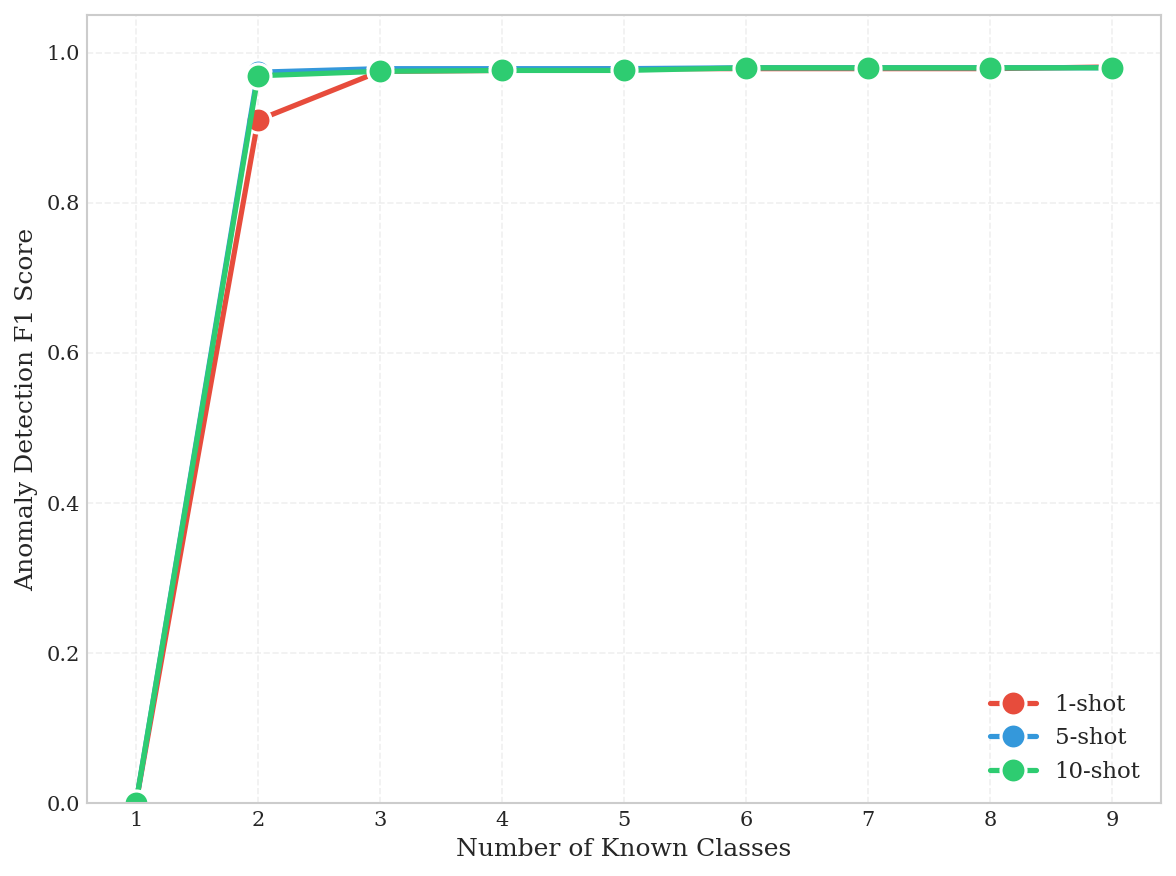

✓ Saved: paper_figures/siamese_anomaly_final.pdf


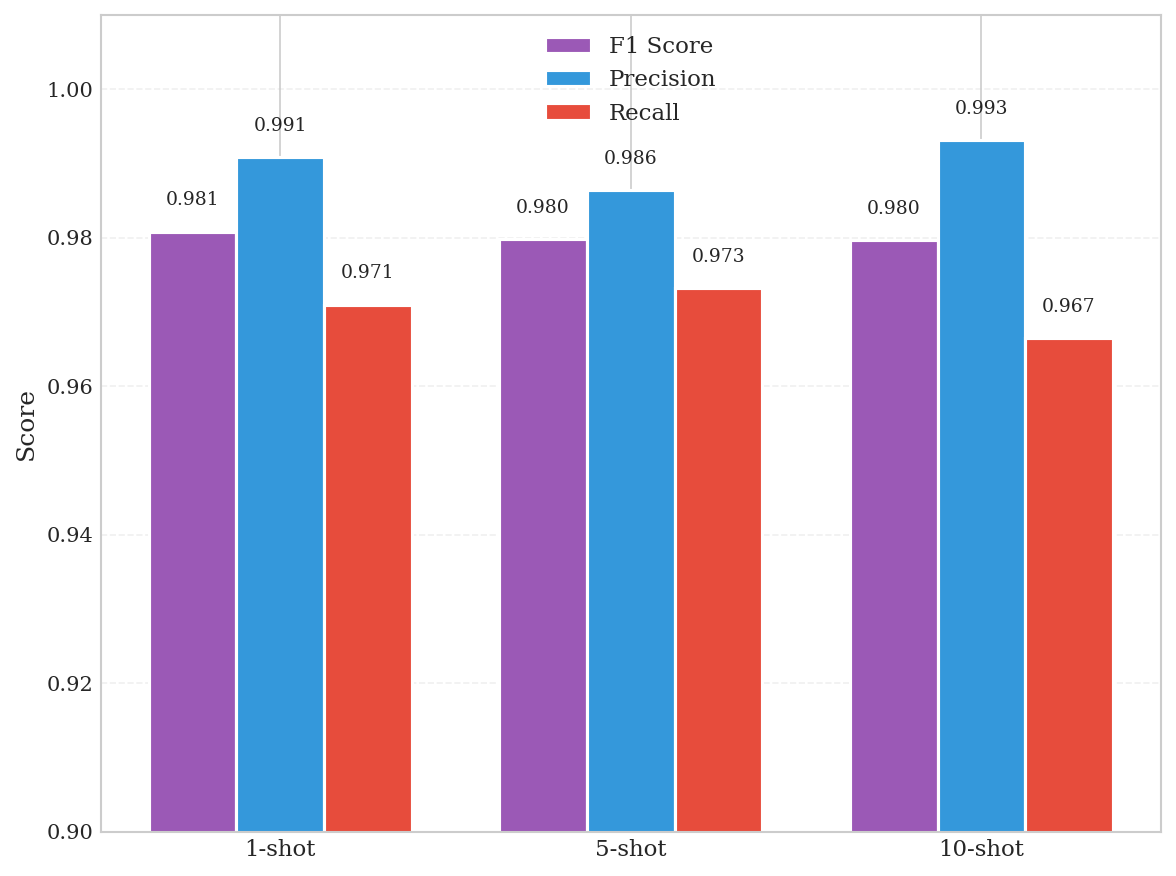

In [12]:
# Plot Siamese Anomaly Detection Performance - Separate Plots

def plot_anomaly_detection_incremental(siamese_results, output_dir):
    """Plot incremental anomaly detection F1 over steps."""
    if 'all_results' not in siamese_results or 'simulation_results' not in siamese_results['all_results']:
        print("⚠ No simulation results found")
        return
    
    sim = siamese_results['all_results']['simulation_results']
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    colors = {1: '#e74c3c', 5: '#3498db', 10: '#2ecc71'}
    
    for shot_key, shot_name in [(1, '1-shot'), (5, '5-shot'), (10, '10-shot')]:
        if shot_key in sim:
            steps = [s['n_known_classes'] for s in sim[shot_key]]
            f1_scores = [s['anomaly_f1'] for s in sim[shot_key]]
            
            ax.plot(steps, f1_scores, marker='o', label=shot_name, 
                   color=colors[shot_key], linewidth=2.5, markersize=12,
                   markeredgecolor='white', markeredgewidth=1.5, markevery=1)
    
    ax.set_xlabel('Number of Known Classes', fontsize=12)
    ax.set_ylabel('Anomaly Detection F1 Score', fontsize=12)
    ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=11, loc='lower right')
    ax.set_xticks(range(1, 10))
    
    plt.tight_layout()
    
    output_path = Path(output_dir) / "siamese_anomaly_incremental.pdf"
    plt.savefig(output_path, bbox_inches='tight', dpi=300)
    print(f"✓ Saved: {output_path}")
    plt.show()

def plot_anomaly_detection_final(siamese_results, output_dir):
    """Plot final anomaly detection performance comparison."""
    if 'all_results' not in siamese_results or 'simulation_results' not in siamese_results['all_results']:
        print("⚠ No simulation results found")
        return
    
    sim = siamese_results['all_results']['simulation_results']
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    shot_names = []
    f1_vals = []
    precision_vals = []
    recall_vals = []
    
    for shot_key, shot_label in [(1, '1-shot'), (5, '5-shot'), (10, '10-shot')]:
        if shot_key in sim:
            final = sim[shot_key][-1]
            shot_names.append(shot_label)
            f1_vals.append(final['anomaly_f1'])
            precision_vals.append(final['anomaly_precision'])
            recall_vals.append(final['anomaly_recall'])
    
    x = np.arange(len(shot_names))
    width = 0.25
    
    ax.bar(x - width, f1_vals, width, label='F1 Score', color='#9b59b6', edgecolor='white', linewidth=1.5)
    ax.bar(x, precision_vals, width, label='Precision', color='#3498db', edgecolor='white', linewidth=1.5)
    ax.bar(x + width, recall_vals, width, label='Recall', color='#e74c3c', edgecolor='white', linewidth=1.5)
    
    ax.set_ylabel('Score', fontsize=12)
    ax.set_ylim([0.9, 1.01])
    ax.set_xticks(x)
    ax.set_xticklabels(shot_names, fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    
    # Add value labels on bars
    for i, (f1, prec, rec) in enumerate(zip(f1_vals, precision_vals, recall_vals)):
        ax.text(i - width, f1 + 0.003, f'{f1:.3f}', ha='center', va='bottom', fontsize=9)
        ax.text(i, prec + 0.003, f'{prec:.3f}', ha='center', va='bottom', fontsize=9)
        ax.text(i + width, rec + 0.003, f'{rec:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    
    output_path = Path(output_dir) / "siamese_anomaly_final.pdf"
    plt.savefig(output_path, bbox_inches='tight', dpi=300)
    print(f"✓ Saved: {output_path}")
    plt.show()

# Generate both plots
plot_anomaly_detection_incremental(siamese_results, OUTPUT_DIR)
plot_anomaly_detection_final(siamese_results, OUTPUT_DIR)

✓ Saved: paper_figures/siamese_nway_kshot_accuracy.pdf


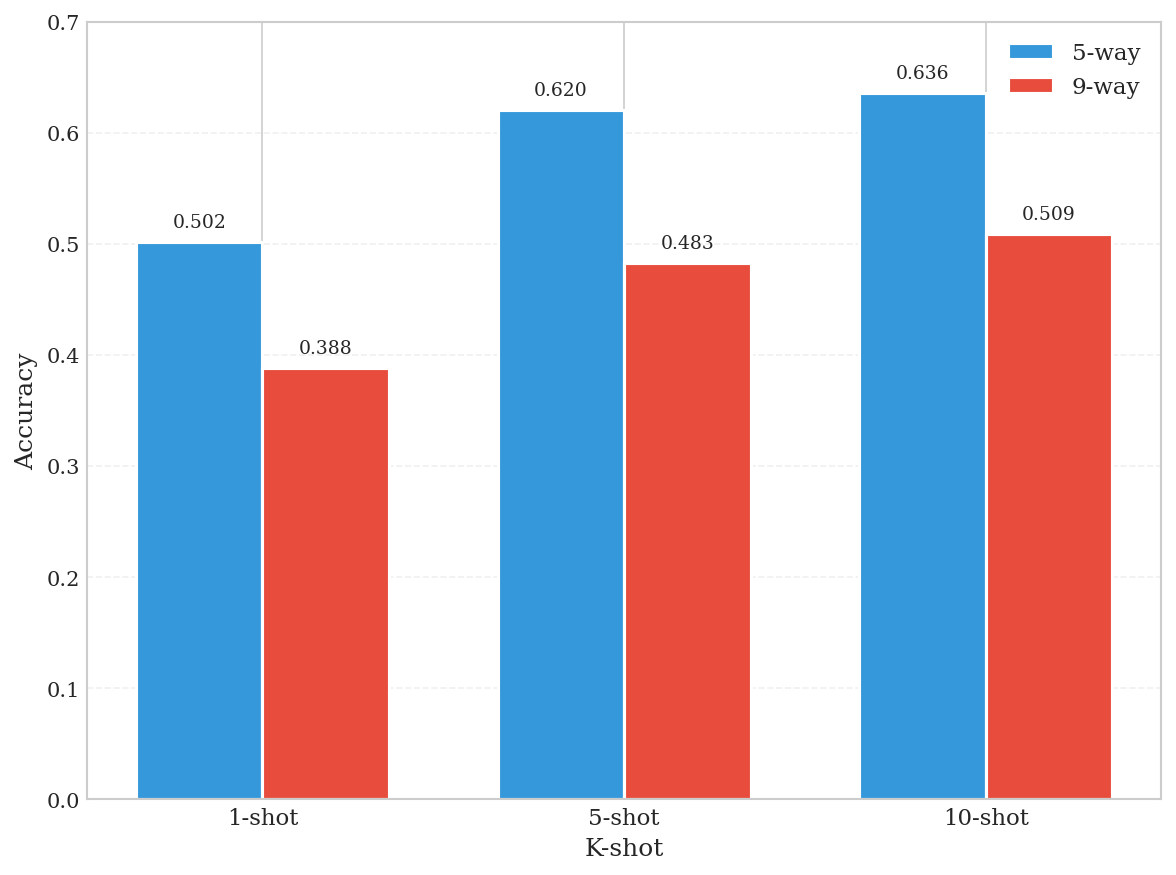

✓ Saved: paper_figures/siamese_5way_kshot.pdf


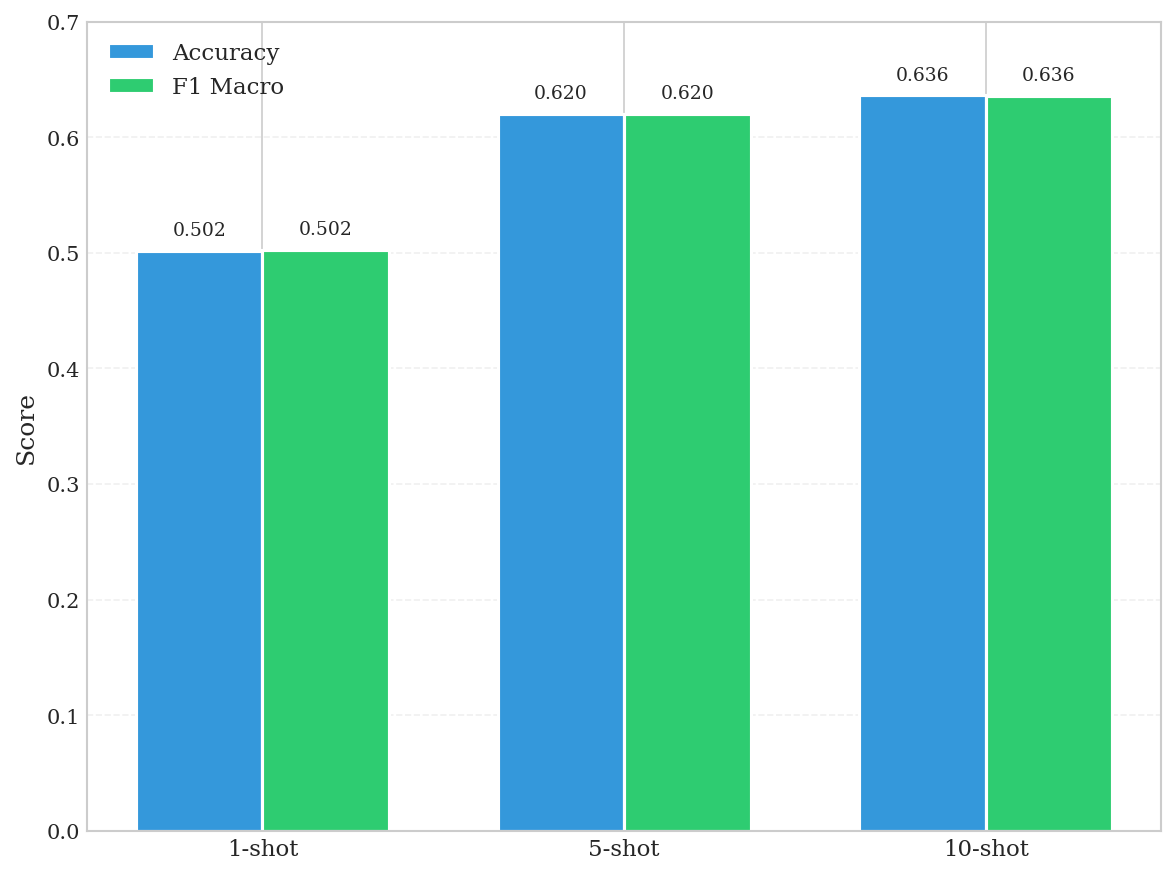

✓ Saved: paper_figures/siamese_9way_kshot.pdf


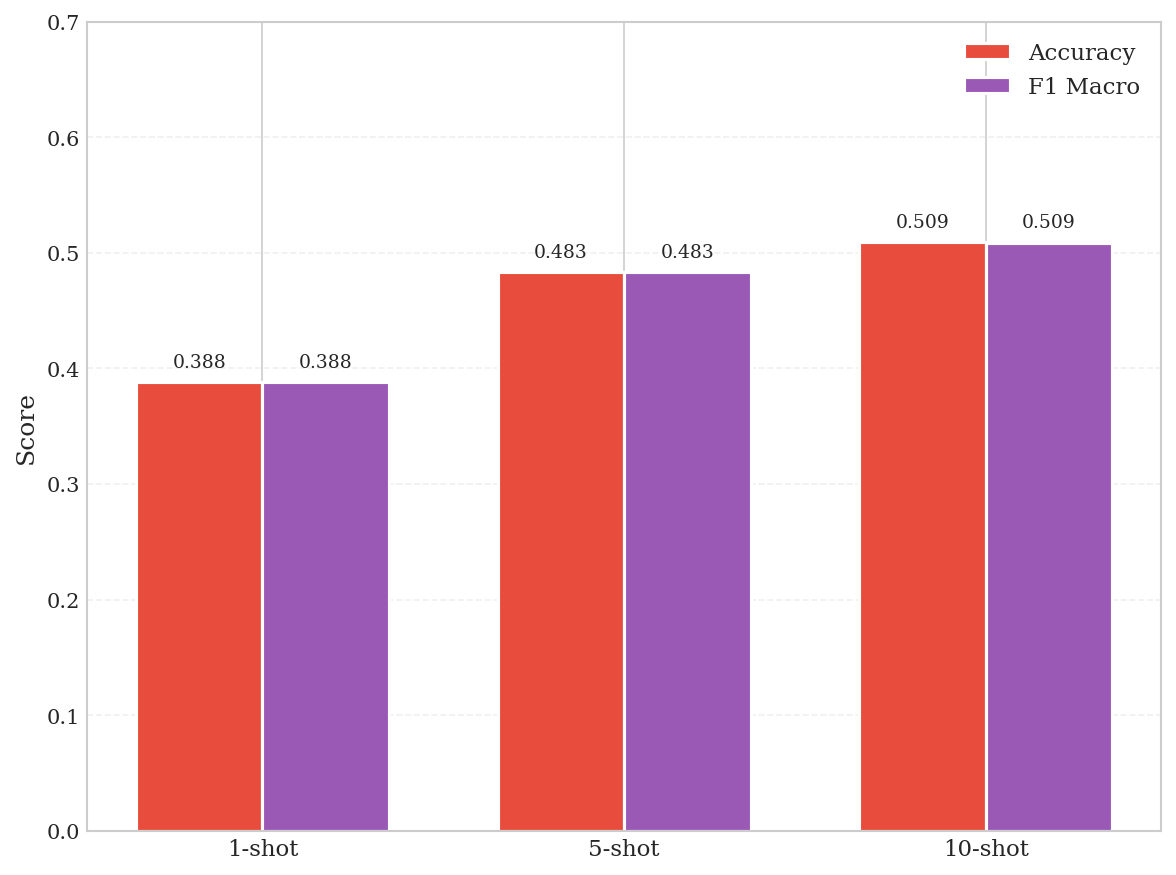

In [5]:
# Plot N-way K-shot Classification Results - Individual Plots

def plot_nway_kshot_accuracy(siamese_results, output_dir):
    """Plot N-way K-shot classification accuracy comparison."""
    if 'all_results' not in siamese_results or 'nway_results' not in siamese_results['all_results']:
        print("⚠ No N-way K-shot results found")
        return
    
    nway = siamese_results['all_results']['nway_results']
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Prepare data
    k_shots = [1, 5, 10]
    acc_5way = [nway[f'5way_{k}shot']['accuracy'] for k in k_shots]
    acc_9way = [nway[f'9way_{k}shot']['accuracy'] for k in k_shots]
    
    x = np.arange(len(k_shots))
    width = 0.35
    
    ax.bar(x - width/2, acc_5way, width, label='5-way', color='#3498db', 
           edgecolor='white', linewidth=1.5)
    ax.bar(x + width/2, acc_9way, width, label='9-way', color='#e74c3c', 
           edgecolor='white', linewidth=1.5)
    
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_xlabel('K-shot', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(['1-shot', '5-shot', '10-shot'], fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax.set_ylim([0, 0.7])
    
    # Add value labels
    for i, (v5, v9) in enumerate(zip(acc_5way, acc_9way)):
        ax.text(i - width/2, v5 + 0.01, f'{v5:.3f}', ha='center', va='bottom', fontsize=9)
        ax.text(i + width/2, v9 + 0.01, f'{v9:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    
    output_path = Path(output_dir) / "siamese_nway_kshot_accuracy.pdf"
    plt.savefig(output_path, bbox_inches='tight', dpi=300)
    print(f"✓ Saved: {output_path}")
    plt.show()

def plot_5way_kshot(siamese_results, output_dir):
    """Plot 5-way K-shot performance."""
    if 'all_results' not in siamese_results or 'nway_results' not in siamese_results['all_results']:
        print("⚠ No N-way K-shot results found")
        return
    
    nway = siamese_results['all_results']['nway_results']
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    k_shots = ['1-shot', '5-shot', '10-shot']
    acc_5way = [nway[f'5way_{k}shot']['accuracy'] for k in [1, 5, 10]]
    f1_5way = [nway[f'5way_{k}shot']['f1_macro'] for k in [1, 5, 10]]
    
    x = np.arange(len(k_shots))
    width = 0.35
    
    ax.bar(x - width/2, acc_5way, width, label='Accuracy', color='#3498db', 
           edgecolor='white', linewidth=1.5)
    ax.bar(x + width/2, f1_5way, width, label='F1 Macro', color='#2ecc71', 
           edgecolor='white', linewidth=1.5)
    
    ax.set_ylabel('Score', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(k_shots, fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax.set_ylim([0, 0.7])
    
    # Add value labels
    for i, (acc, f1) in enumerate(zip(acc_5way, f1_5way)):
        ax.text(i - width/2, acc + 0.01, f'{acc:.3f}', ha='center', va='bottom', fontsize=9)
        ax.text(i + width/2, f1 + 0.01, f'{f1:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    
    output_path = Path(output_dir) / "siamese_5way_kshot.pdf"
    plt.savefig(output_path, bbox_inches='tight', dpi=300)
    print(f"✓ Saved: {output_path}")
    plt.show()

def plot_9way_kshot(siamese_results, output_dir):
    """Plot 9-way K-shot performance."""
    if 'all_results' not in siamese_results or 'nway_results' not in siamese_results['all_results']:
        print("⚠ No N-way K-shot results found")
        return
    
    nway = siamese_results['all_results']['nway_results']
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    k_shots = ['1-shot', '5-shot', '10-shot']
    acc_9way = [nway[f'9way_{k}shot']['accuracy'] for k in [1, 5, 10]]
    f1_9way = [nway[f'9way_{k}shot']['f1_macro'] for k in [1, 5, 10]]
    
    x = np.arange(len(k_shots))
    width = 0.35
    
    ax.bar(x - width/2, acc_9way, width, label='Accuracy', color='#e74c3c', 
           edgecolor='white', linewidth=1.5)
    ax.bar(x + width/2, f1_9way, width, label='F1 Macro', color='#9b59b6', 
           edgecolor='white', linewidth=1.5)
    
    ax.set_ylabel('Score', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(k_shots, fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax.set_ylim([0, 0.7])
    
    # Add value labels
    for i, (acc, f1) in enumerate(zip(acc_9way, f1_9way)):
        ax.text(i - width/2, acc + 0.01, f'{acc:.3f}', ha='center', va='bottom', fontsize=9)
        ax.text(i + width/2, f1 + 0.01, f'{f1:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    
    output_path = Path(output_dir) / "siamese_9way_kshot.pdf"
    plt.savefig(output_path, bbox_inches='tight', dpi=300)
    print(f"✓ Saved: {output_path}")
    plt.show()

# Generate all N-way K-shot plots
plot_nway_kshot_accuracy(siamese_results, OUTPUT_DIR)
plot_5way_kshot(siamese_results, OUTPUT_DIR)
plot_9way_kshot(siamese_results, OUTPUT_DIR)

## Complete Metrics Summary

In [5]:
# Print comprehensive metrics for all models
def print_all_metrics():
    """Print all metrics for CNN, MLP, and Siamese models."""
    
    print('='*80)
    print('COMPREHENSIVE RESULTS SUMMARY - ALL MODELS')
    print('='*80)
    
    # CNN Results
    print('\n1. CNN RESULTS')
    print('-'*80)
    if cnn_results['test'] is not None:
        test = cnn_results['test']
        print(f"  Test Samples:        {len(test['predictions']):,}")
        print(f"  Accuracy:            {test['accuracy']*100:.2f}%")
        print(f"  Balanced Accuracy:   {test['balanced_accuracy']*100:.2f}%")
        print(f"  F1 Macro:            {test['f1_macro']:.4f}")
        print(f"  F1 Weighted:         {test['f1_weighted']:.4f}")
    else:
        print("  ⚠ No test results available")
    
    # MLP Results
    print('\n2. MLP RESULTS')
    print('-'*80)
    if mlp_results['test'] is not None:
        test = mlp_results['test']
        print(f"  Test Samples:        {len(test['predictions']):,}")
        print(f"  Accuracy:            {test['accuracy']*100:.2f}%")
        print(f"  Balanced Accuracy:   {test['balanced_accuracy']*100:.2f}%")
        print(f"  F1 Macro:            {test['f1_macro']:.4f}")
        print(f"  F1 Weighted:         {test['f1_weighted']:.4f}")
    else:
        print("  ⚠ No test results available")
    
    # Siamese Results
    print('\n3. SIAMESE NETWORK RESULTS')
    print('-'*80)
    
    if 'all_results' in siamese_results:
        all_res = siamese_results['all_results']
        
        # 5-class standard test
        if 'test_results_5class' in all_res:
            test_5 = all_res['test_results_5class']
            print('\n  3.1 Standard Test (5 Training Classes)')
            print(f"      Test Samples:        {len(test_5['predictions']):,}")
            print(f"      Accuracy:            {test_5['accuracy']*100:.2f}%")
            print(f"      Balanced Accuracy:   {test_5['balanced_accuracy']*100:.2f}%")
            print(f"      F1 Macro:            {test_5['f1_macro']:.4f}")
            print(f"      F1 Weighted:         {test_5['f1_weighted']:.4f}")
        
        # 9-class 10-shot test
        if siamese_results['test'] is not None:
            test_9 = siamese_results['test']
            print('\n  3.2 Few-Shot Test (9 Classes, 10-shot)')
            print(f"      Test Samples:        {len(test_9['predictions']):,}")
            print(f"      Accuracy:            {test_9['accuracy']*100:.2f}%")
            print(f"      Balanced Accuracy:   {test_9['balanced_accuracy']*100:.2f}%")
            print(f"      F1 Macro:            {test_9['f1_macro']:.4f}")
            print(f"      F1 Weighted:         {test_9['f1_weighted']:.4f}")
        
        # N-way K-shot results
        if 'nway_results' in all_res:
            nway = all_res['nway_results']
            print('\n  3.3 N-way K-shot Classification')
            print('      5-way:')
            for k in [1, 5, 10]:
                key = f'5way_{k}shot'
                if key in nway:
                    acc = nway[key]['accuracy'] * 100
                    f1 = nway[key]['f1_macro']
                    std = nway[key]['accuracy_std'] * 100
                    print(f'        {k:2d}-shot:  Acc={acc:5.2f}% (±{std:.2f}%), F1={f1:.4f}')
            
            print('      9-way:')
            for k in [1, 5, 10]:
                key = f'9way_{k}shot'
                if key in nway:
                    acc = nway[key]['accuracy'] * 100
                    f1 = nway[key]['f1_macro']
                    std = nway[key]['accuracy_std'] * 100
                    print(f'        {k:2d}-shot:  Acc={acc:5.2f}% (±{std:.2f}%), F1={f1:.4f}')
        
        # Anomaly detection results
        if 'simulation_results' in all_res:
            sim = all_res['simulation_results']
            print('\n  3.4 Anomaly Detection (Binary: Regular vs Others)')
            for k in [1, 5, 10]:
                if k in sim and len(sim[k]) > 0:
                    final = sim[k][-1]
                    f1 = final['anomaly_f1'] * 100
                    prec = final['anomaly_precision'] * 100
                    rec = final['anomaly_recall'] * 100
                    print(f'      {k:2d}-shot:  F1={f1:.2f}%, Prec={prec:.2f}%, Rec={rec:.2f}%')
    else:
        print("  ⚠ No comprehensive results available")
    
    # Quick summary
    print('\n' + '='*80)
    print('QUICK SUMMARY')
    print('='*80)
    if cnn_results['test'] is not None:
        cnn_acc = cnn_results['test']['accuracy'] * 100
        cnn_samples = len(cnn_results['test']['predictions'])
        print(f"CNN:     {cnn_acc:.2f}% acc ({cnn_samples:,} samples, 9 classes)")
    
    if mlp_results['test'] is not None:
        mlp_acc = mlp_results['test']['accuracy'] * 100
        mlp_samples = len(mlp_results['test']['predictions'])
        print(f"MLP:     {mlp_acc:.2f}% acc ({mlp_samples:,} samples, 9 classes)")
    
    if 'all_results' in siamese_results:
        all_res = siamese_results['all_results']
        if 'test_results_5class' in all_res:
            s5_acc = all_res['test_results_5class']['accuracy'] * 100
            s5_samples = len(all_res['test_results_5class']['predictions'])
            print(f"Siamese: {s5_acc:.2f}% acc ({s5_samples:,} samples, 5 classes)")
        
        if siamese_results['test'] is not None:
            s9_acc = siamese_results['test']['accuracy'] * 100
            s9_samples = len(siamese_results['test']['predictions'])
            print(f"         {s9_acc:.2f}% acc ({s9_samples:,} samples, 9-class 10-shot)")
        
        if 'simulation_results' in all_res and 10 in all_res['simulation_results']:
            sim_f1 = all_res['simulation_results'][10][-1]['anomaly_f1'] * 100
            print(f"         {sim_f1:.2f}% F1  (anomaly detection)")
    
    print('='*80)

# Run the summary
print_all_metrics()

COMPREHENSIVE RESULTS SUMMARY - ALL MODELS

1. CNN RESULTS
--------------------------------------------------------------------------------
  Test Samples:        32,447
  Accuracy:            87.39%
  Balanced Accuracy:   63.78%
  F1 Macro:            0.6192
  F1 Weighted:         0.8563

2. MLP RESULTS
--------------------------------------------------------------------------------
  Test Samples:        11,865
  Accuracy:            76.08%
  Balanced Accuracy:   71.57%
  F1 Macro:            0.7212
  F1 Weighted:         0.7586

3. SIAMESE NETWORK RESULTS
--------------------------------------------------------------------------------

  3.1 Standard Test (5 Training Classes)
      Test Samples:        435
      Accuracy:            74.71%
      Balanced Accuracy:   74.71%
      F1 Macro:            0.7477
      F1 Weighted:         0.7477

  3.2 Few-Shot Test (9 Classes, 10-shot)
      Test Samples:        414
      Accuracy:            46.38%
      Balanced Accuracy:   46.38%
    

## Generate IEEE-Formatted Results Table

In [6]:
def generate_results_latex_table(cnn_results, mlp_results, siamese_all_results, 
                                  output_file='paper_figures/results_comparison.tex'):
    """
    Generate IEEE-formatted LaTeX table with test results for all models including
    all Siamese N-way K-shot variations.
    
    Siamese uses 5 similarity metrics: L1, L2, Cosine, Product, Attention Fusion
    
    Args:
        cnn_results: CNN test results dict
        mlp_results: MLP test results dict
        siamese_all_results: Siamese all_results dict containing nway_results
        output_file: Path to save the LaTeX table
    """
    import os
    
    # Ensure output directory exists
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    
    # Build table data
    table_data = []
    
    # CNN row
    table_data.append({
        'model': 'CNN',
        'accuracy': cnn_results.get('accuracy', 0) * 100,
        'balanced_accuracy': cnn_results.get('balanced_accuracy', 0) * 100,
        'f1_macro': cnn_results.get('f1_macro', 0) * 100,
        'f1_weighted': cnn_results.get('f1_weighted', 0) * 100
    })
    
    # MLP row
    table_data.append({
        'model': 'MLP',
        'accuracy': mlp_results.get('accuracy', 0) * 100,
        'balanced_accuracy': mlp_results.get('balanced_accuracy', 0) * 100,
        'f1_macro': mlp_results.get('f1_macro', 0) * 100,
        'f1_weighted': mlp_results.get('f1_weighted', 0) * 100
    })
    
    # Siamese N-way K-shot rows (no balanced accuracy)
    nway_results = siamese_all_results.get('nway_results', {})
    siamese_test_direct = siamese_all_results.get('test_results', {})
    
    siamese_configs = [
        ('5way_1shot', 'Siamese 5-way 1-shot'),
        ('5way_5shot', 'Siamese 5-way 5-shot'),
        ('5way_10shot', 'Siamese 5-way 10-shot'),
        ('9way_1shot', 'Siamese 9-way 1-shot'),
        ('9way_5shot', 'Siamese 9-way 5-shot'),
        ('9way_10shot', 'Siamese 9-way 10-shot'),
    ]
    
    for config_key, config_name in siamese_configs:
        # Use test_results directly for 9-way 10-shot to match confusion matrix
        if config_key == '9way_10shot' and siamese_test_direct:
            res = siamese_test_direct
        elif config_key in nway_results:
            res = nway_results[config_key]
        else:
            continue
            
        table_data.append({
            'model': config_name,
            'accuracy': res.get('accuracy', 0) * 100,
            'balanced_accuracy': None,  # Not computed for few-shot
            'f1_macro': res.get('f1_macro', 0) * 100,
            'f1_weighted': res.get('f1_weighted', 0) * 100
        })
    
    # Generate LaTeX table with metrics as rows and models as columns
    latex_table = r"""\begin{table*}[htbp]
\centering
\caption{Test Performance Comparison: CNN, MLP, and Siamese N-way K-shot Evaluations}
\label{tab:results_comparison}
\begin{tabular}{|l|c|c|cccccc|}
\hline
\textbf{Metric} & \textbf{CNN} & \textbf{MLP} & \multicolumn{6}{c|}{\textbf{Siamese (Multi-Similarity)}} \\
\cline{4-9}
 & & & \textbf{5w-1s} & \textbf{5w-5s} & \textbf{5w-10s} & \textbf{9w-1s} & \textbf{9w-5s} & \textbf{9w-10s} \\
\hline
"""
    
    # Extract data organized by metric
    metrics_config = [
        ('Accuracy (\\%)', 'accuracy'),
        ('Balanced Acc.$^{a}$ (\\%)', 'balanced_accuracy'),
        ('F1 Macro (\\%)', 'f1_macro'),
        ('F1 Weighted (\\%)', 'f1_weighted')
    ]
    
    for metric_label, metric_key in metrics_config:
        values = []
        for row in table_data:
            val = row[metric_key]
            if val is None:
                values.append('---')
            else:
                values.append(f"{val:.2f}")
        
        latex_table += f"{metric_label} & "
        latex_table += ' & '.join(values)
        latex_table += r" \\" + "\n"
        latex_table += r"\hline" + "\n"
    
    latex_table += r"""\end{tabular}
\\[2mm]
{\small
\begin{tabular}{@{}l@{}}
$^{a}$Balanced Accuracy only computed for CNN/MLP (not available for few-shot evaluation)\\
\textit{Note:} 5w = 5-way, 9w = 9-way; 1s/5s/10s = 1-shot/5-shot/10-shot
\end{tabular}
}
\end{table*}"""
    
    # Save to file
    with open(output_file, 'w') as f:
        f.write(latex_table)
    
    print(f"LaTeX table saved to: {output_file}")
    print("\nGenerated LaTeX table:")
    print("=" * 80)
    print(latex_table)
    print("=" * 80)
    
    # Also print as DataFrame for easy viewing
    import pandas as pd
    df = pd.DataFrame(table_data)
    print("\nTable as DataFrame:")
    print("=" * 80)
    print(df.to_string(index=False))
    print("=" * 80)
    
    return latex_table


# Load all test results
import numpy as np
import pickle

cnn_test = np.load('cnn_results_20260120_094712/test_results.npy', allow_pickle=True).item()
mlp_test = np.load('mlp_results_20260122_040240/test_results.npy', allow_pickle=True).item()

# Load Siamese comprehensive results with all N-way K-shot evaluations
with open('siamese_multisim_20260122_132947/all_results.pkl', 'rb') as f:
    siamese_all = pickle.load(f)

# Also load the direct test results for consistency with confusion matrix
siamese_test_direct = np.load('siamese_multisim_20260122_132947/test_results.npy', allow_pickle=True).item()
siamese_all['test_results'] = siamese_test_direct

# Generate the comprehensive table
latex_table = generate_results_latex_table(cnn_test, mlp_test, siamese_all)

LaTeX table saved to: paper_figures/results_comparison.tex

Generated LaTeX table:
\begin{table*}[htbp]
\centering
\caption{Test Performance Comparison: CNN, MLP, and Siamese N-way K-shot Evaluations}
\label{tab:results_comparison}
\begin{tabular}{|l|c|c|cccccc|}
\hline
\textbf{Metric} & \textbf{CNN} & \textbf{MLP} & \multicolumn{6}{c|}{\textbf{Siamese (Multi-Similarity)}} \\
\cline{4-9}
 & & & \textbf{5w-1s} & \textbf{5w-5s} & \textbf{5w-10s} & \textbf{9w-1s} & \textbf{9w-5s} & \textbf{9w-10s} \\
\hline
Accuracy (\%) & 87.39 & 76.08 & 50.18 & 62.00 & 63.60 & 38.78 & 48.29 & 46.38 \\
\hline
Balanced Acc.$^{a}$ (\%) & 63.78 & 71.57 & --- & --- & --- & --- & --- & --- \\
\hline
F1 Macro (\%) & 61.92 & 72.12 & 50.23 & 62.00 & 63.59 & 38.79 & 48.29 & 44.11 \\
\hline
F1 Weighted (\%) & 85.63 & 75.86 & 50.23 & 62.00 & 63.59 & 38.79 & 48.29 & 44.11 \\
\hline
\end{tabular}
\\m]
{\small
\begin{tabular}{@{}l@{}}
$^{a}$Balanced Accuracy only computed for CNN/MLP (not available for few-shot evalua